Lag Distance (ft) | Variogram Value | Number of Pairs
------------------|------------------|----------------
               10 |             5.64 |              7
               20 |            11.92 |              6
               30 |             8.00 |              5
               40 |             9.25 |              4
               50 |            16.33 |              3
               60 |             9.25 |              2
               70 |             0.50 |              1


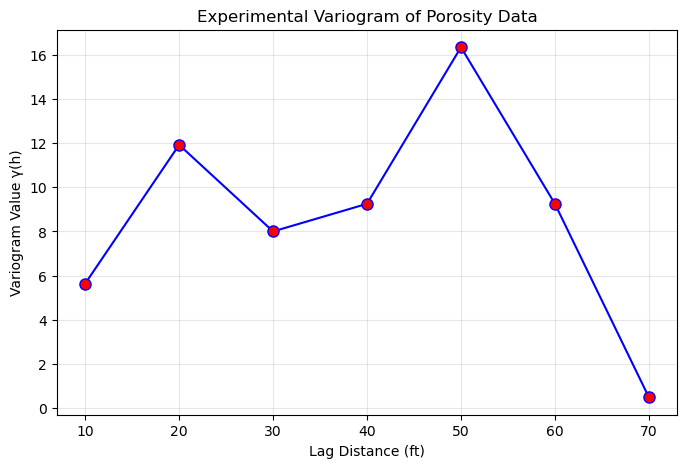

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
depths = np.array([0, 10, 20, 30, 40, 50, 60, 70])  # in feet
porosity = np.array([23, 18, 15, 21, 23, 22, 22, 24])  # in %

# Calculate all possible pairs
n = len(depths)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        h = depths[j] - depths[i]  # lag distance
        diff = porosity[i] - porosity[j]  # difference in porosity
        pairs.append((h, diff**2))  # store lag and squared difference

# Calculate variogram values for each lag
unique_lags = np.unique(depths[1:] - depths[0])  # possible lag distances (10, 20,...,70)
variogram = []
for h in unique_lags:
    # Find all squared differences for this lag
    squared_diffs = [diff for lag, diff in pairs if lag == h]
    # Calculate gamma(h) = average of squared differences / 2
    gamma_h = np.sum(squared_diffs) / (2 * len(squared_diffs))
    variogram.append((h, gamma_h, len(squared_diffs)))  # store lag, gamma(h), and number of pairs

# Print the results in a table
print("Lag Distance (ft) | Variogram Value | Number of Pairs")
print("------------------|------------------|----------------")
for h, gamma, n_pairs in variogram:
    print(f"{h:17} | {gamma:16.2f} | {n_pairs:14}")

# Plot the variogram
lags = [h for h, gamma, n_pairs in variogram]
gamma_values = [gamma for h, gamma, n_pairs in variogram]

plt.figure(figsize=(8, 5))
plt.plot(lags, gamma_values, 'bo-', markerfacecolor='red', markersize=8)
plt.title('Experimental Variogram of Porosity Data')
plt.xlabel('Lag Distance (ft)')
plt.ylabel('Variogram Value γ(h)')
plt.grid(True, alpha=0.3)
plt.xticks(lags)
plt.show()

In [3]:
import numpy as np
from scipy.linalg import solve

# Input data (depth in feet, porosity in %)
data = np.array([
    [10, 18],
    [20, 15],
    [30, 21],
    [40, 23]
])

# Estimation point
estimation_point = 25

# Variogram model (from part a)
def variogram(h):
    # Linear interpolation of the experimental variogram
    known_points = {
        0: 0,
        10: 5.64,
        20: 11.92,
        30: 8.00,
        40: 9.25,
        50: 16.33,
        60: 9.25,
        70: 0.50
    }
    h_floor = 10 * (h // 10)
    h_ceil = h_floor + 10
    if h in known_points:
        return known_points[h]
    elif h_floor in known_points and h_ceil in known_points:
        # Linear interpolation
        return known_points[h_floor] + (h - h_floor) * (known_points[h_ceil] - known_points[h_floor]) / 10
    else:
        return 0  # for h=0

# Create the kriging system
n = len(data)
A = np.zeros((n+1, n+1))
b = np.zeros(n+1)

# Fill matrix A (variogram between data points)
for i in range(n):
    for j in range(n):
        h = abs(data[i, 0] - data[j, 0])
        A[i, j] = variogram(h)
    A[i, n] = 1  # Lagrange multiplier column
    A[n, i] = 1  # Lagrange multiplier row
A[n, n] = 0  # Bottom right element

# Fill vector b (variogram between data points and estimation point)
for i in range(n):
    h = abs(data[i, 0] - estimation_point)
    b[i] = variogram(h)
b[n] = 1  # Constraint sum of weights = 1

# Solve the kriging system
weights = solve(A, b)
lambda_weights = weights[:-1]  # The actual weights
mu = weights[-1]  # Lagrange multiplier

# Calculate the estimate
estimate = np.sum(lambda_weights * data[:, 1])

# Calculate the estimation variance
estimation_variance = np.sum(lambda_weights * b[:-1]) - mu

# Print results
print("Kriging Matrix A:")
print(np.array2string(A, precision=2, suppress_small=True))
print("\nRight-hand Side Vector b:")
print(np.array2string(b, precision=2, suppress_small=True))
print("\nSolution Vector [weights, mu]:")
print(np.array2string(weights, precision=4, suppress_small=True))
print("\nKriging Results:")
print(f"Weight for {data[0,0]}ft: {lambda_weights[0]:.4f}")
print(f"Weight for {data[1,0]}ft: {lambda_weights[1]:.4f}")
print(f"Weight for {data[2,0]}ft: {lambda_weights[2]:.4f}")
print(f"Weight for {data[3,0]}ft: {lambda_weights[3]:.4f}")
print(f"Lagrange multiplier (μ): {mu:.4f}")
print(f"\nEstimated porosity at {estimation_point}ft: {estimate:.2f}%")
print(f"Estimation variance: {estimation_variance:.4f}")

Kriging Matrix A:
[[ 0.    5.64 11.92  8.    1.  ]
 [ 5.64  0.    5.64 11.92  1.  ]
 [11.92  5.64  0.    5.64  1.  ]
 [ 8.   11.92  5.64  0.    1.  ]
 [ 1.    1.    1.    1.    0.  ]]

Right-hand Side Vector b:
[8.78 2.82 2.82 8.78 1.  ]

Solution Vector [weights, mu]:
[ 0.   0.5  0.5 -0.   0. ]

Kriging Results:
Weight for 10ft: 0.0000
Weight for 20ft: 0.5000
Weight for 30ft: 0.5000
Weight for 40ft: -0.0000
Lagrange multiplier (μ): 0.0000

Estimated porosity at 25ft: 18.00%
Estimation variance: 2.8200


In [ ]:
S